# Import  dependencies

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Import dataset from this..

In [32]:

data = pd.read_csv('bank.csv',sep = ";")
data


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [3]:
data.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

# 1)  Audit Data Types and Missing Values

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


# 2) How to check missing value is dataset and calculate percentage of missing value for each column

In [5]:
percentage  = (data.isnull().sum() / data.shape[0])* 100
percentage


age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64

# 3) check Duplicates

In [7]:
print('duplicate value:',data.duplicated().sum())

duplicate value: 0


# 4) check number of unique values in each column.

In [8]:
data.nunique()

age            67
job            12
marital         3
education       4
default         2
balance      2353
housing         2
loan            2
contact         3
day            31
month          12
duration      875
campaign       32
pdays         292
previous       24
poutcome        4
y               2
dtype: int64

# 5) How to find IQR for outlier detection?

In [9]:
q1 = data['age'].quantile(0.25)
q3 = data['age'].quantile(0.75)
iqr = q1 - q3
iqr

-16.0

In [10]:
q1

33.0

In [11]:
q3

49.0

In [33]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the data
df_filtered = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]

In [34]:
df_filtered

,Unnamed: 0,age,marital,education,default,balance,housing,loan,contact,day,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,0,30,1,0,no,1787,no,0,cellular,19,...,0,0,0,0,0,0,0,0,1,0
2,2,35,2,2,no,1350,yes,0,cellular,16,...,0,0,1,0,0,0,0,0,0,0
3,3,30,1,2,no,1476,yes,1,unknown,3,...,0,0,1,0,0,0,0,0,0,0
4,4,59,1,1,no,0,yes,0,unknown,5,...,0,0,0,0,0,0,0,0,0,0
5,5,35,2,2,no,747,no,0,cellular,23,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4515,4515,32,2,1,no,473,yes,0,cellular,7,...,0,0,0,0,0,1,0,0,0,0
4516,4516,33,1,1,no,-333,yes,0,cellular,30,...,0,0,0,0,0,1,0,0,0,0
4518,4518,57,1,1,no,295,no,0,cellular,19,...,0,0,0,0,0,0,0,1,0,0
4519,4519,28,1,1,no,1137,no,0,cellular,6,...,0,0,0,0,0,0,0,0,0,0


In [35]:
pdays_Q1 = df['balance'].quantile(0.25)
pdays_Q3 = df['balance'].quantile(0.75)
IQR = pdays_Q3 - pdays_Q1

lower_bound = pdays_Q1 - 1.5 * IQR
upper_bound = pdays_Q3 + 1.5 * IQR

# Filtering the data
df_filtered_1 = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]
df_filtered_1

,Unnamed: 0,age,marital,education,default,balance,housing,loan,contact,day,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,0,30,1,0,no,1787,no,0,cellular,19,...,0,0,0,0,0,0,0,0,1,0
2,2,35,2,2,no,1350,yes,0,cellular,16,...,0,0,1,0,0,0,0,0,0,0
3,3,30,1,2,no,1476,yes,1,unknown,3,...,0,0,1,0,0,0,0,0,0,0
4,4,59,1,1,no,0,yes,0,unknown,5,...,0,0,0,0,0,0,0,0,0,0
5,5,35,2,2,no,747,no,0,cellular,23,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4515,4515,32,2,1,no,473,yes,0,cellular,7,...,0,0,0,0,0,1,0,0,0,0
4516,4516,33,1,1,no,-333,yes,0,cellular,30,...,0,0,0,0,0,1,0,0,0,0
4518,4518,57,1,1,no,295,no,0,cellular,19,...,0,0,0,0,0,0,0,1,0,0
4519,4519,28,1,1,no,1137,no,0,cellular,6,...,0,0,0,0,0,0,0,0,0,0


# 6) remove outliers using IQR rule?

In [10]:
data = data[(data['age'] > q1 - 1.5*iqr) & (data['age'] < q3 + 1.5*iqr)]
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


# 7) detect outliers visually using a plot

{'whiskers': [<matplotlib.lines.Line2D at 0x1bb7ac2a710>,
 'caps': [<matplotlib.lines.Line2D at 0x1bb7ac2ac50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bb7ac2a470>],
 'medians': [<matplotlib.lines.Line2D at 0x1bb7ac2b190>],
 'fliers': [<matplotlib.lines.Line2D at 0x1bb7ac2b430>],
 'means': []}

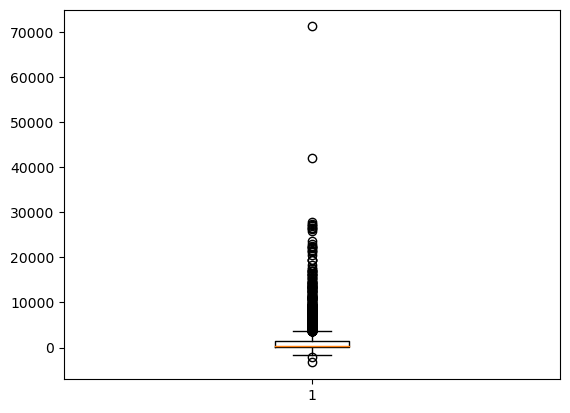

In [36]:
plt.boxplot(data['balance'])

# 8) compare two numerical variables graphically

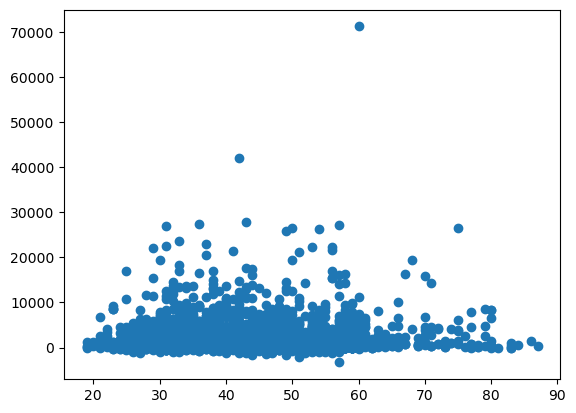

In [37]:
plt.scatter(data['age'],data['balance'])

# 9)Label Encoding

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['marital'] = le.fit_transform(data['marital'])
data['marital']

0       1
1       1
2       2
3       1
4       1
       ..
4516    1
4517    1
4518    1
4519    1
4520    2
Name: marital, Length: 4521, dtype: int32

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['education'] = le.fit_transform(data['education'])
data['education']

0       0
1       1
2       2
3       2
4       1
       ..
4516    1
4517    2
4518    1
4519    1
4520    2
Name: education, Length: 4521, dtype: int32

In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['loan'] = le.fit_transform(data['loan'])
data['loan']

0       0
1       1
2       0
3       1
4       0
       ..
4516    0
4517    1
4518    0
4519    0
4520    1
Name: loan, Length: 4521, dtype: int32

In [55]:
binary_cols = ['default', 'housing']
for col in binary_cols:
    if col in data.columns and data[col].dtype == 'object':
        data[col] = data[col].map({'yes': 1, 'no': 0})

In [56]:
data

,age,marital,education,default,balance,housing,loan,day,duration,campaign,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,1,0,0,1787,0,0,19,79,1,...,0,0,0,0,0,1,0,0,0,1
1,33,1,1,0,4789,1,1,11,220,1,...,0,0,0,1,0,0,0,0,0,0
2,35,2,2,0,1350,1,0,16,185,1,...,0,0,0,0,0,0,0,0,0,0
3,30,1,2,0,1476,1,1,3,199,4,...,0,1,0,0,0,0,0,0,0,1
4,59,1,1,0,0,1,0,5,226,1,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,1,1,0,-333,1,0,30,329,5,...,1,0,0,0,0,0,0,0,0,1
4517,57,1,2,1,-3313,1,1,9,153,1,...,0,0,0,1,0,0,0,0,0,1
4518,57,1,1,0,295,0,0,19,151,11,...,0,0,0,0,0,0,0,0,0,1
4519,28,1,1,0,1137,0,0,6,129,4,...,0,0,0,0,0,0,0,1,0,0


# 10)One-Hot Encoding

In [ ]:
data = pd.get_dummies(data, columns=['job'])
data

In [ ]:
data = pd.get_dummies(data, columns=['contact', 'month', 'poutcome'], drop_first=True)
data

# 11) normalize numerical features

In [58]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
minmax = scaler.fit_transform(data[['age','balance']])


In [59]:
minmax

array([[0.16176471, 0.06845546],
       [0.20588235, 0.10875022],
       [0.23529412, 0.06258976],
       ...,
       [0.55882353, 0.04842888],
       [0.13235294, 0.05973074],
       [0.36764706, 0.05971732]])

# 12) standardize features

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
std= scaler.fit_transform(data[['age','balance']])


In [61]:
std

array([[-1.05626965,  0.12107186],
       [-0.77258281,  1.1186443 ],
       [-0.58345826, -0.02414438],
       ...,
       [ 1.49691189, -0.37472364],
       [-1.24539421, -0.09492484],
       [ 0.26760226, -0.09525714]])

# 13) perform train-test split

In [62]:
X = data.drop('y', axis=1)

In [63]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['y'] = le.fit_transform(data['y'])
data['y']

0       0
1       0
2       0
3       0
4       0
       ..
4516    0
4517    0
4518    0
4519    0
4520    0
Name: y, Length: 4521, dtype: int64

In [64]:
import sklearn
sklearn.__version__

'1.2.1'

In [65]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, data.y, test_size=0.2, random_state=42)
X_train

,age,marital,education,default,balance,housing,loan,day,duration,campaign,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
978,34,0,2,0,262,0,0,20,371,1,...,0,0,0,0,1,0,0,0,0,1
251,32,1,2,0,2349,0,0,14,134,5,...,0,0,0,0,0,0,0,0,0,1
3139,34,2,1,0,1076,0,0,8,70,2,...,0,0,0,0,0,0,0,0,0,1
1822,31,1,2,0,156,0,0,13,657,7,...,0,0,0,0,0,0,0,0,0,1
4445,46,1,0,0,258,1,0,27,217,1,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,41,1,2,0,1536,0,0,4,54,2,...,0,0,0,1,0,0,0,0,0,1
466,34,1,1,0,-370,1,0,21,748,1,...,0,0,0,1,0,0,0,0,0,1
3092,46,1,2,0,523,1,0,6,105,4,...,0,0,0,1,0,0,0,0,0,0
3772,47,2,2,0,440,0,0,21,71,4,...,0,0,0,0,0,0,0,0,0,1


In [50]:
y_test

2398    0
800     0
2288    0
2344    0
3615    0
       ..
3589    1
3128    0
3259    0
4239    0
2233    1
Name: y, Length: 905, dtype: int32

## convrt to csv

In [67]:
data.to_csv("clear_bank.csv")